<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Classification and KNN with NHL data

_Authors: Joseph Nelson (DC)_

---

Below you will practice KNN classification on a dataset of NHL statistics.

You will be predicting the `Rank` of a team from predictor variables of your choice.

In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# web location:
local_csv = '../data/NHL_Data_GA.csv'

### 1. Load the NHL data

In [3]:
# A:
df=pd.read_csv('./data/NHL_Data_GA.csv')

### 2. Perform any required data cleaning. Do some EDA.

In [4]:
# A:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Team    90 non-null     str    
 1   PTS     90 non-null     int64  
 2   Rank    90 non-null     int64  
 3   TOI     90 non-null     str    
 4   GF      90 non-null     int64  
 5   GA      90 non-null     int64  
 6   GF60    90 non-null     float64
 7   GA60    90 non-null     float64
 8   GF%     90 non-null     float64
 9   SF      90 non-null     int64  
 10  SA      90 non-null     int64  
 11  SF60    90 non-null     float64
 12  SA60    90 non-null     float64
 13  SF%     90 non-null     float64
 14  FF      90 non-null     int64  
 15  FA      90 non-null     int64  
 16  FF60    90 non-null     float64
 17  FA60    90 non-null     float64
 18  FF%     90 non-null     float64
 19  CF      90 non-null     int64  
 20  CA      90 non-null     int64  
 21  CF60    90 non-null     float64
 22  CA60    90 non-

In [5]:
df.isnull().sum()

Team    0
PTS     0
Rank    0
TOI     0
GF      0
GA      0
GF60    0
GA60    0
GF%     0
SF      0
SA      0
SF60    0
SA60    0
SF%     0
FF      0
FA      0
FF60    0
FA60    0
FF%     0
CF      0
CA      0
CF60    0
CA60    0
CF%     0
Sh%     0
Sv%     0
PDO     0
PIM     0
dtype: int64

In [6]:
df['Rank'].value_counts().sort_index()

Rank
1    29
2    30
3    31
Name: count, dtype: int64

In [7]:
# Summary statistics for numeric features
df.describe()

,PTS,Rank,GF,GA,GF60,GA60,GF%,SF,SA,SF60,...,FF%,CF,CA,CF60,CA60,CF%,Sh%,Sv%,PDO,PIM
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,...,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,91.977778,2.022222,83.288889,83.288889,2.442222,2.444000,49.981111,1068.333333,1068.333333,31.252222,...,49.966667,1973.466667,1973.466667,57.735556,57.798889,49.972222,7.814556,92.182556,999.988889,990.966667
std,12.524114,0.820767,10.376339,9.694484,0.325331,0.313522,4.644554,95.929047,75.514118,2.237637,...,2.797913,176.468299,154.148928,4.124476,4.291106,2.844313,0.866942,0.928621,12.292772,178.049321
min,62.000000,1.000000,57.000000,64.000000,1.700000,1.730000,38.000000,815.000000,868.000000,25.800000,...,43.100000,1565.000000,1572.000000,49.500000,46.700000,43.700000,5.900000,89.830000,978.000000,689.000000
25%,82.250000,1.000000,76.000000,75.500000,2.232500,2.202500,46.825000,1011.500000,1022.250000,29.550000,...,47.775000,1855.250000,1877.000000,54.275000,54.600000,47.925000,7.235000,91.555000,992.000000,881.250000
50%,92.500000,2.000000,84.000000,84.000000,2.400000,2.495000,49.700000,1072.000000,1072.000000,31.400000,...,50.050000,1981.500000,1961.000000,58.050000,58.350000,50.400000,7.730000,92.250000,1000.500000,960.000000
75%,102.000000,3.000000,90.000000,89.000000,2.600000,2.670000,53.625000,1143.000000,1125.750000,32.775000,...,51.775000,2112.750000,2077.250000,60.850000,60.400000,52.000000,8.270000,92.870000,1007.750000,1101.500000
max,121.000000,3.000000,115.000000,107.000000,3.450000,3.240000,61.200000,1311.000000,1245.000000,35.600000,...,58.100000,2341.000000,2332.000000,64.900000,67.500000,57.100000,10.340000,93.940000,1034.000000,1515.000000


### 3. Set up the `Rank` variable as your target. How many classes are there?

In [11]:
# A:
y = df['Rank']

num_classes = y.nunique()
num_classes


3

### 4. What is the baseline accuracy?

In [12]:
baseline = df['Rank'].value_counts().max() / len(df)
baseline

np.float64(0.34444444444444444)

### 5. Choose 4 features to be your predictor variables and set up your design matrix.

In [22]:
df.columns

Index(['Team', 'PTS', 'Rank', 'TOI', 'GF', 'GA', 'GF60', 'GA60', 'GF%', 'SF',
       'SA', 'SF60', 'SA60', 'SF%', 'FF', 'FA', 'FF60', 'FA60', 'FF%', 'CF',
       'CA', 'CF60', 'CA60', 'CF%', 'Sh%', 'Sv%', 'PDO', 'PIM'],
      dtype='str')

In [14]:
X = df[['PTS', 'GF', 'GA', 'PDO']]
y = df['Rank']

print(f"feature (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Preview top rows 
X.head()

feature (X) shape: (90, 4)
Target (y) shape: (90,)


,PTS,GF,GA,PDO
0,121,115,73,1034
1,117,94,72,1014
2,113,90,68,1019
3,112,104,83,992
4,111,86,74,1013


### 6. Fit a `KNeighborsClassifier` with 1 neighbor using the target and predictors.

In [16]:
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[1,2,3]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### 7. Evaluate the accuracy of your model.
- Is it better than baseline?
- Is it legitimate?

In [18]:
accuracy = knn.score(X, y)
accuracy

1.0

**Is it better than baseline?**

Yes. The model accuracy is 1.0 (100%), which is much higher than the baseline accuracy of 34.4%.

**Is it legitimate?**

No. The model was evaluated on the same data it was trained on, so the accuracy is overly optimistic. A train/test split or cross-validation is needed to evaluate its true performance.

### 8. Create a 50-50 train-test-split of your target and predictors. Refit the KNN and assess the accuracy.

In [19]:
# A:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.50,stratify=y, random_state=42)

ss = StandardScaler()
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
accuracy = knn.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.8444444444444444


### 9. Evaluate the test accuracy of a KNN where K == number of rows in the training data.

In [23]:
# A:
k = X_train.shape[0]

knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train, y_train)

accuracy = knn.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.3111111111111111


### 10. Fit the KNN at values of K from 1 to the number of rows in the training data.
- Store the test accuracy in a list.
- Plot the test accuracy vs. the number of neighbors.

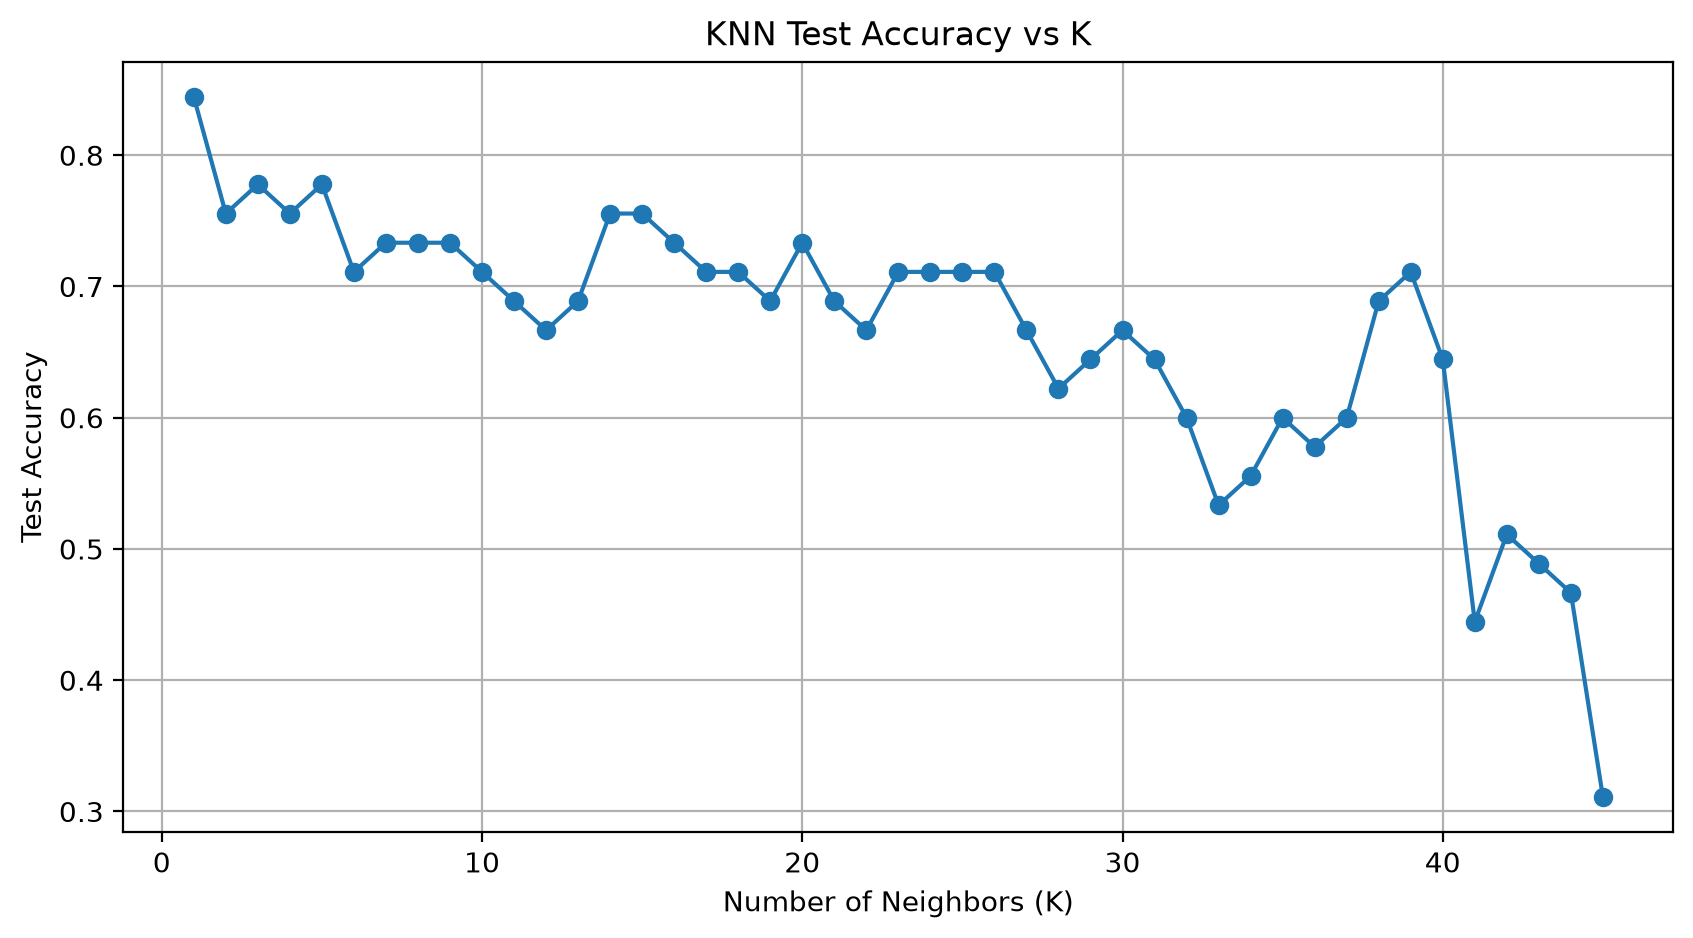

In [24]:
# A:
test_accuracy = []
for k in range(1, X_train.shape[0] + 1):
    
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train, y_train)
    
    accuracy = knn.score(X_test, y_test)
    
    test_accuracy.append(accuracy)


plt.figure(figsize=(10, 5))

plt.plot(
    range(1, X_train.shape[0] + 1),
    test_accuracy,
    marker='o'
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Test Accuracy")
plt.title("KNN Test Accuracy vs K")
plt.grid()

plt.show()

### 11. Fit KNN across different values of K and plot the mean cross-validated accuracy with 5 folds.

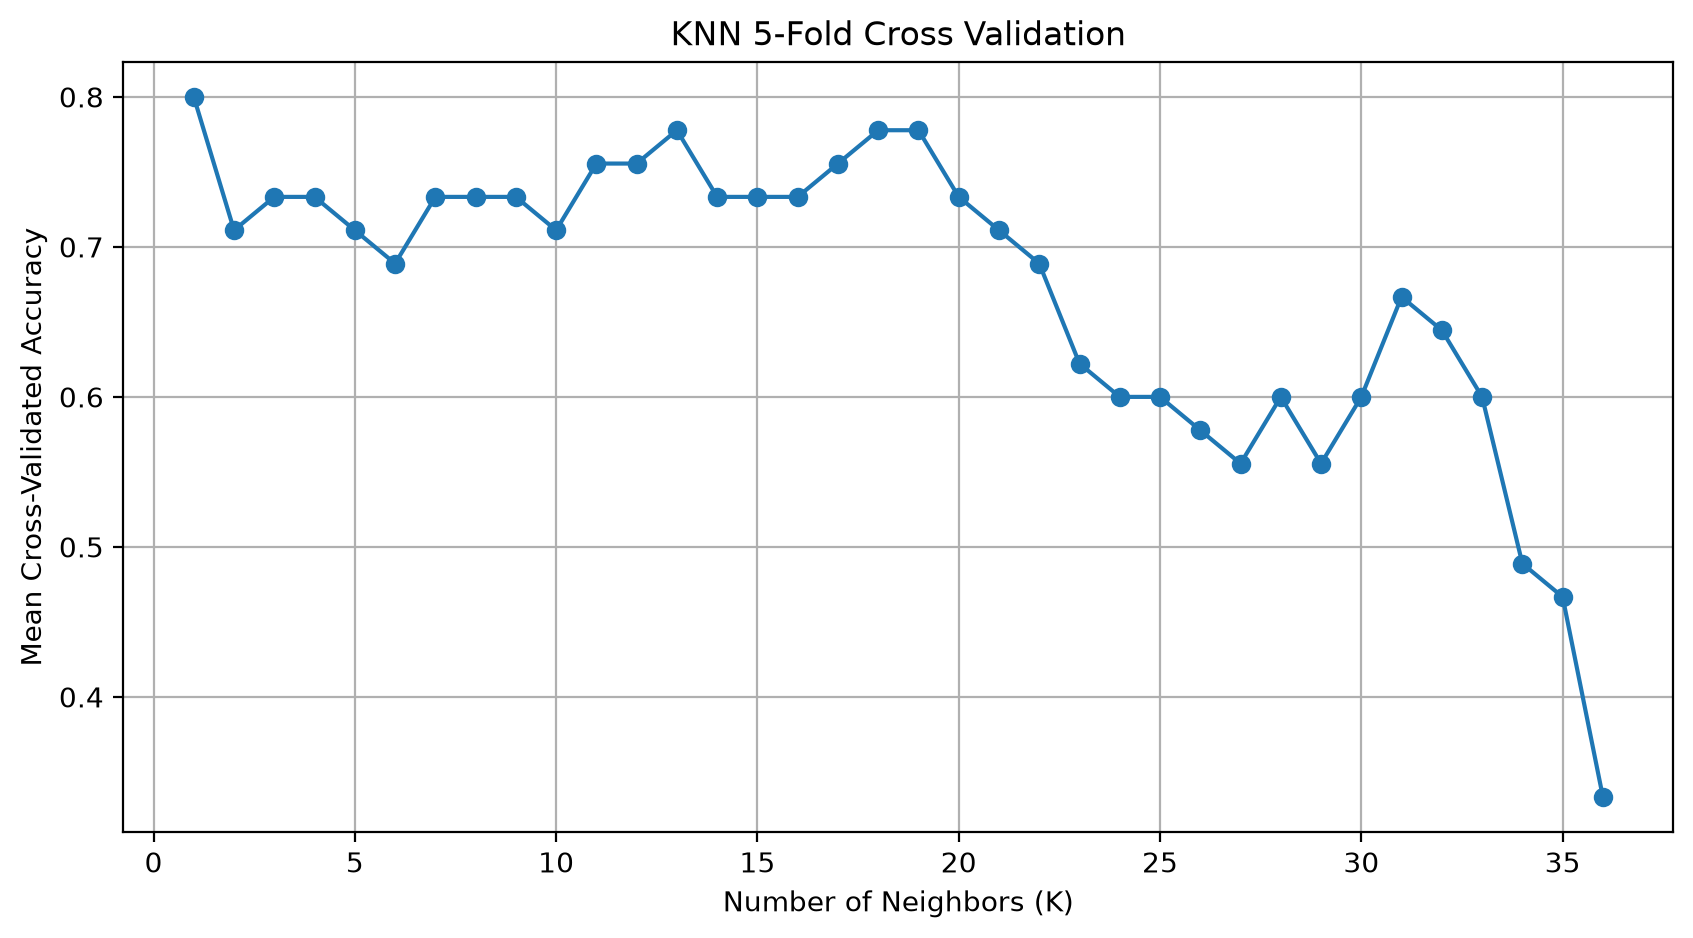

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

cv_accuracy = []

# maximum possible K for 5-fold CV
max_k = int(X_train.shape[0] * 0.8)

for k in range(1, max_k + 1):

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    cv_accuracy.append(scores.mean())


plt.figure(figsize=(10,5))

plt.plot(
    range(1, max_k + 1),
    cv_accuracy,
    marker='o'
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Cross-Validated Accuracy")
plt.title("KNN 5-Fold Cross Validation")

plt.grid()
plt.show()

### 12. Standardize the predictor matrix and cross-validate across the different K.
- Plot the standardized mean cross-validated accuracy against the unstandardized. Which is better?
- Why?

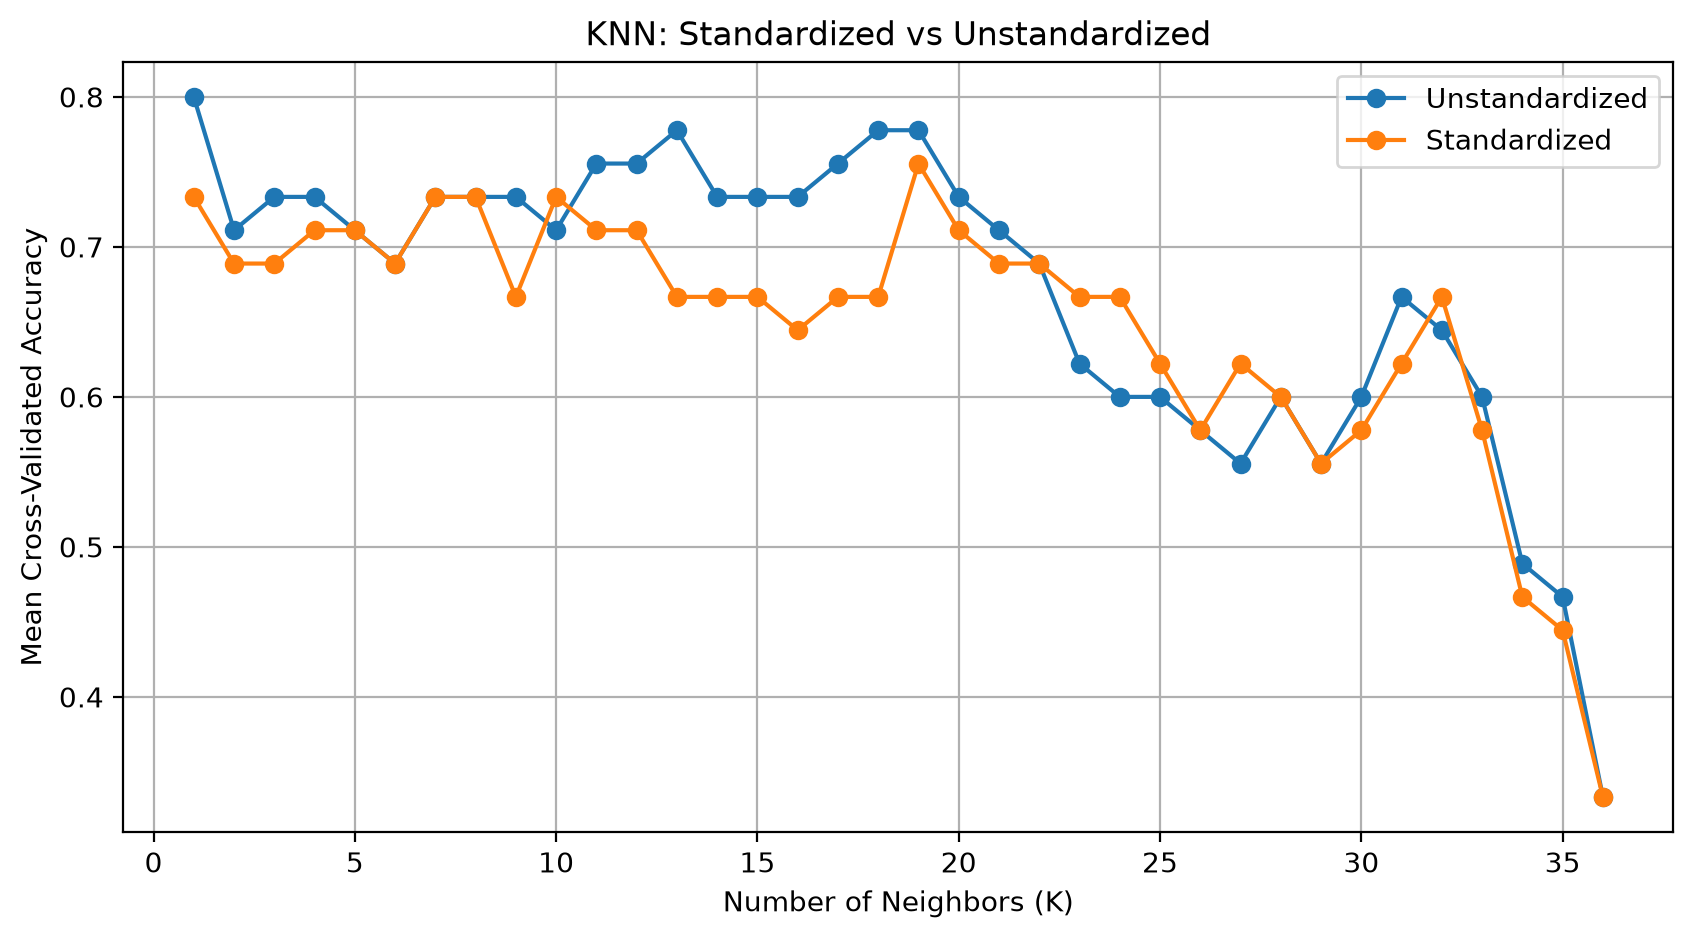

In [37]:
ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)

cv_accuracy_scaled = []

maxk = int(X_train.shape[0] * 0.8)

for k in range(1, maxk + 1):

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    cv_accuracy_scaled.append(scores.mean())



plt.figure(figsize=(10,5))

plt.plot(
    range(1, maxk + 1),
    cv_accuracy,
    marker='o',
    label='Unstandardized'
)

plt.plot(
    range(1, maxk + 1),
    cv_accuracy_scaled,
    marker='o',
    label='Standardized'
)


plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Cross-Validated Accuracy")
plt.title("KNN: Standardized vs Unstandardized")

plt.legend()
plt.grid()
plt.show()

In [32]:
print("Best Unstandardized:", max(cv_accuracy))
print("Best Standardized:", max(cv_accuracy_scaled))

Best Unstandardized: 0.8
Best Standardized: 0.7555555555555554


## What was the best 'k'?

Using `GridSearch` & `Pipeline` find the best `k` for the KNN model

In [35]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])


param_grid = {
    'knn__n_neighbors': range(1, int(X_train.shape[0]*0.8) + 1)
}
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)
print("Best K:", grid.best_params_['knn__n_neighbors'])
print("Best Accuracy:", grid.best_score_)

Best K: 19
Best Accuracy: 0.8
